# Tutorial para [cmblensplus](https://toshiyan.github.io/clpdoc/html/index.html)

La idea es usar este paquete para hacer delensing interno.
En adelante usaremos los mapas de r = 0 (sin foreground, ni ruido)

In [9]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# ---------------
# Ruta de los mapas
# ---------------

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/r_0.0/"

nside = 512
lmax = 1000
N_alm = (lmax + 1)*(lmax + 2)/2

# lista de alms orden T, E y B 
names = np.array(["T", "E" , "B"])
alms_total = []
alms_unlensed = []
for i, name in enumerate(names):

    data = np.load(os.path.join(ruta,f"cmb_alms_total.npz"))
    alm = data[f"alm{name}"]  #.astype(np.complex64)
    alms_total.append(alm)

    data1 = np.load(os.path.join(ruta,"cmb_alms_unlensed.npz"))
    alm1 = data1[f"alm{name}"] #.astype(np.complex64)
    alms_unlensed.append(alm1)
    
    data2 = np.load(os.path.join(ruta,"cmb_alms_phi.npz"))
    alm_phi = data2["alm_phi"] #.astype(np.complex64)
    
# Lista de Cls reales
names1 = np.array(["TT", "EE", "BB", "TE"])

Cl_total = []
Cl_unlensed = []
for name in names1:
    tot_cl =  np.loadtxt(os.path.join(ruta, f"Cl_total_{name}.txt"))
    Cl_total.append(tot_cl)
    unl_cl =  np.loadtxt(os.path.join(ruta, f"Cl_unlensed_{name}.txt"))
    Cl_unlensed.append(unl_cl)

Cl_phi = np.loadtxt(os.path.join(ruta, "Cl_phiphi.txt"))
ells = np.loadtxt(os.path.join(ruta, "ells.txt"))

# ells = np.loadtxt(os.path.join(ruta, "ells.txt"))
# Cl_phiphi = np.loadtxt(os.path.join(ruta, "Cl_phiphi.txt"))
# Cl_total_BB = np.loadtxt(os.path.join(ruta, "Cl_total_BB.txt"))
# Cl_total_EE = np.loadtxt(os.path.join(ruta, "Cl_total_EE.txt"))
# Cl_total_TE = np.loadtxt(os.path.join(ruta, "Cl_total_TE.txt"))
# Cl_total_TT = np.loadtxt(os.path.join(ruta, "Cl_total_TT.txt"))
# Cl_unlensed_BB = np.loadtxt(os.path.join(ruta, "Cl_unlensed_BB.txt"))
# Cl_unlensed_EE = np.loadtxt(os.path.join(ruta, "Cl_unlensed_EE.txt"))
# Cl_unlensed_TT = np.loadtxt(os.path.join(ruta, "Cl_unlensed_TT.txt"))
# Cl_unlensed_TE = np.loadtxt(os.path.join(ruta, "Cl_unlensed_TE.txt"))

# map_phiphi = hp.read_map(os.path.join(ruta, "map_phiphi.fits"))
# map_total_Q = hp.read_map(os.path.join(ruta, "map_total_Q.fits"))
# map_total_T = hp.read_map(os.path.join(ruta, "map_total_T.fits"))
# map_total_U = hp.read_map(os.path.join(ruta, "map_total_U.fits"))

# map_unlensed_Q = hp.read_map(os.path.join(ruta, "map_unlensed_Q.fits"))
# map_unlensed_T = hp.read_map(os.path.join(ruta, "map_unlensed_T.fits"))
# map_unlensed_U = hp.read_map(os.path.join(ruta, "map_unlensed_U.fits"))


## Cantidad de alm's

Si tenemos $l_{max} = 1000$ la cantidad de alm's que hay en total se calcula:
$$ N = \sum_{l = 0}^{1000} (2l + 1) = (l_{max} + 1)^2 = 1002001$$

Pero como el cielo es un campo real:

$$ A(\hat n) = \sum a_{l,m} Y_l ^m(\theta, \phi) $$
$$ A^*(\hat n) = \sum a_{l,m}^* (Y_l ^m(\theta, \phi))^* = \sum a_{l,m}^* (-1)^mY_l ^{-m}(\theta, \phi)$$

Entonces $ a_{l,-m} = (-1)^m a_{l,m}^* $ la suma se reduce a:

$$ N = \sum_{l = 0}^{1000} (l + 1) = \frac{(l_{max} + 1)(l_{max} + 2)}{2} = 501501$$

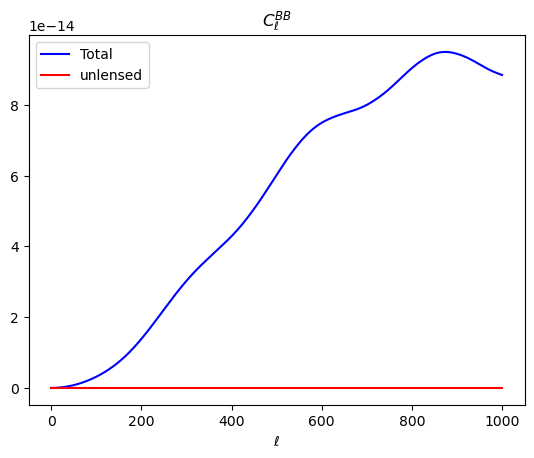

In [10]:
factor = ells*(ells+1)/(2*np.pi)

plt.plot(ells,Cl_total[2]*factor, color='b', label='Total')
plt.plot(ells,Cl_unlensed[2]*factor, color='r', label='unlensed')
plt.xlabel(r'$\ell$')
plt.title(r'$C_\ell^{BB}$')
plt.legend()
plt.show()

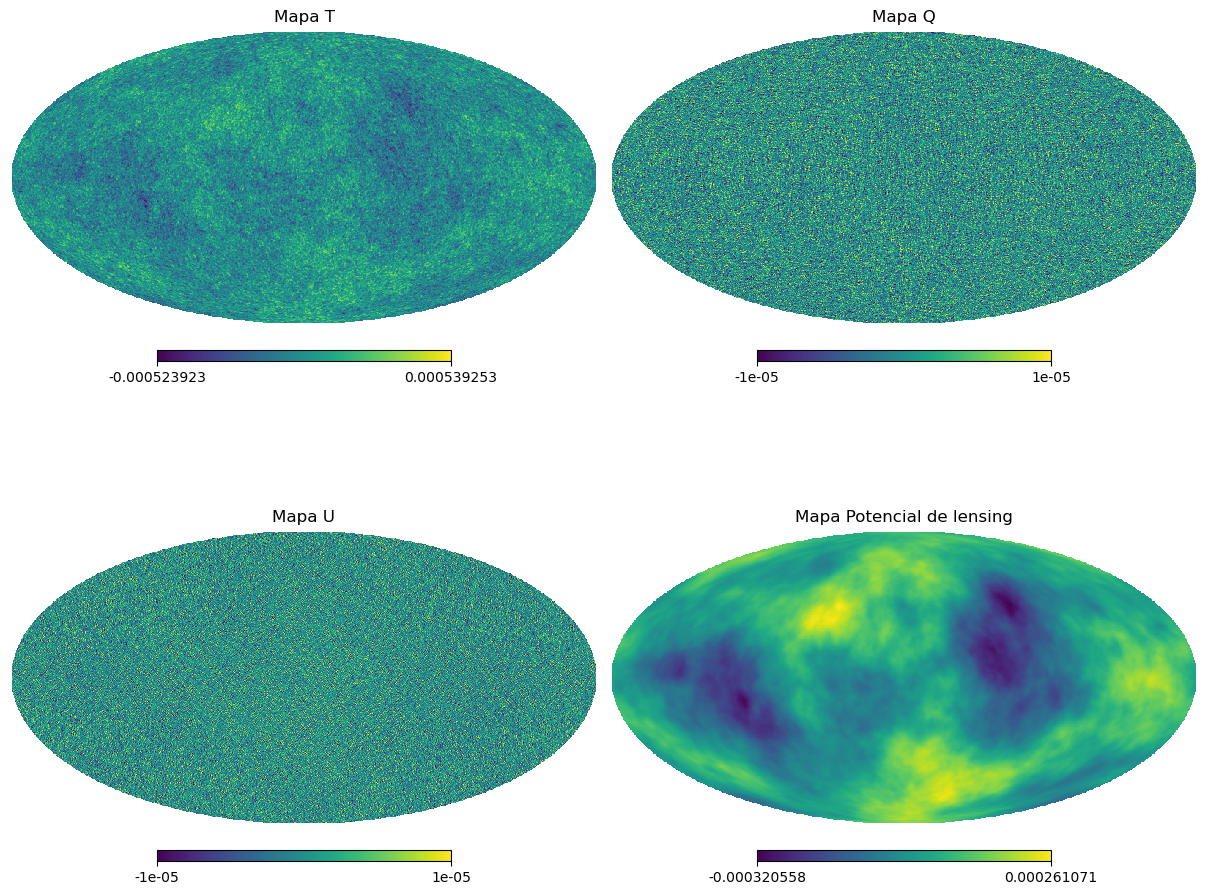

In [11]:
# Mapas T,Q,U 
map_total_T, map_total_Q, map_total_U = hp.alm2map(alms_total, nside=nside, lmax=lmax ,pol=True)
map_unlensed_T, map_unlensed_Q, map_unlensed_U = hp.alm2map(alms_unlensed, nside=nside, lmax=lmax)
map_phi = hp.alm2map(alm_phi, nside=nside, lmax=lmax)

plt.figure(figsize=(12,10))

hp.mollview(map_total_T, title="Mapa T",sub=(2,2,1))
hp.mollview(map_total_Q, title="Mapa Q",min=-1e-5,max=1e-5,sub=(2,2,2))
hp.mollview(map_total_U, title="Mapa U",min=-1e-5,max=1e-5,sub=(2,2,3))
hp.mollview(map_phi, title="Mapa Potencial de lensing",sub=(2,2,4))
plt.show()

De los mapas anteriores me queda la pregunta si este mapa del potencial de lensing logra lensear el mapa unlensed de CAMB y llegar a los mapas totales que estoy graficando... 

Primero transformaremos los mapas Q y U en E y B. 

Y para chequear que es correcto compararemos los Cl's



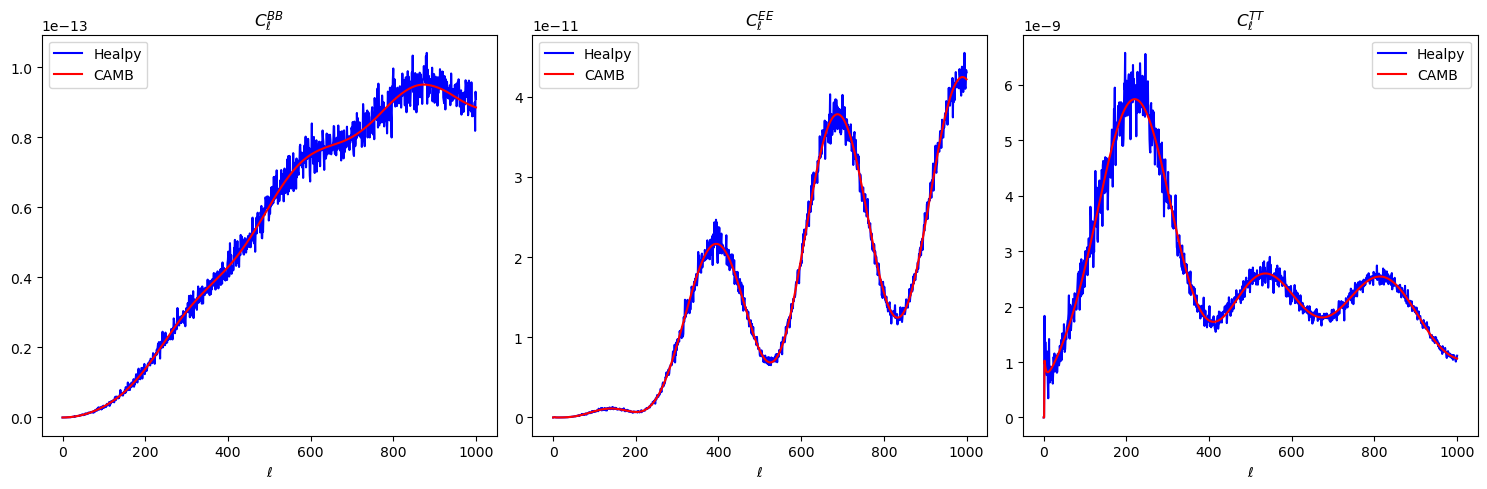

In [12]:
#Para graficar los D_l
factor = ells*(ells+1)/(2*np.pi)

#Transforma los mapas T en alm
alm_total_T = hp.map2alm(map_total_T, lmax=lmax, use_pixel_weights=True)

#Transforma de los mapas Q y U en los alm de spin 2 
alm_total_E, alm_total_B = hp.sphtfunc.map2alm_spin(np.array([map_total_Q,map_total_U]), spin=2, lmax=lmax)

#Verifiquemos que los Cls son similares a los del CAMB
Cl_BB = hp.sphtfunc.alm2cl(alm_total_B,alm_total_B,lmax=lmax)*factor
Cl_EE = hp.sphtfunc.alm2cl(alm_total_E,alm_total_E,lmax=lmax)*factor
Cl_TT = hp.sphtfunc.alm2cl(alm_total_T,alm_total_T,lmax=lmax)*factor

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(ells,Cl_BB,color='b',label='Healpy') 
ax[0].plot(ells, Cl_total[2]*factor,color="r",label='CAMB')
ax[0].set_title(r'$C_\ell^{BB}$')
ax[0].legend()
ax[0].set_xlabel(r'$\ell$')

ax[1].plot(ells,Cl_EE,color='b',label='Healpy') 
ax[1].plot(ells, Cl_total[1]*factor,color="r",label='CAMB')
ax[1].set_title(r'$C_\ell^{EE}$')
ax[1].legend()
ax[1].set_xlabel(r'$\ell$')

ax[2].plot(ells,Cl_TT,color='b',label='Healpy') 
ax[2].plot(ells, Cl_total[0]*factor,color="r",label='CAMB')
ax[2].set_title(r'$C_\ell^{TT}$')
ax[2].legend()
ax[2].set_xlabel(r'$\ell$')

plt.tight_layout()
plt.show()

#Transforma de los alm de spin 2 a mapas de E y B
map_total_E = hp.alm2map(alm_total_E, nside)
map_total_B = hp.alm2map(alm_total_B, nside)



ESTE 'RUIDO' SUPONGO QUE SE PUEDE ELIMINAR SI HACEMOS MAS REALIZACIONES ??


PARA añadir los [FOREGROUNDS VER ESTE LINK](https://www.zonca.dev/posts/2024-04-12-pysm-figures)

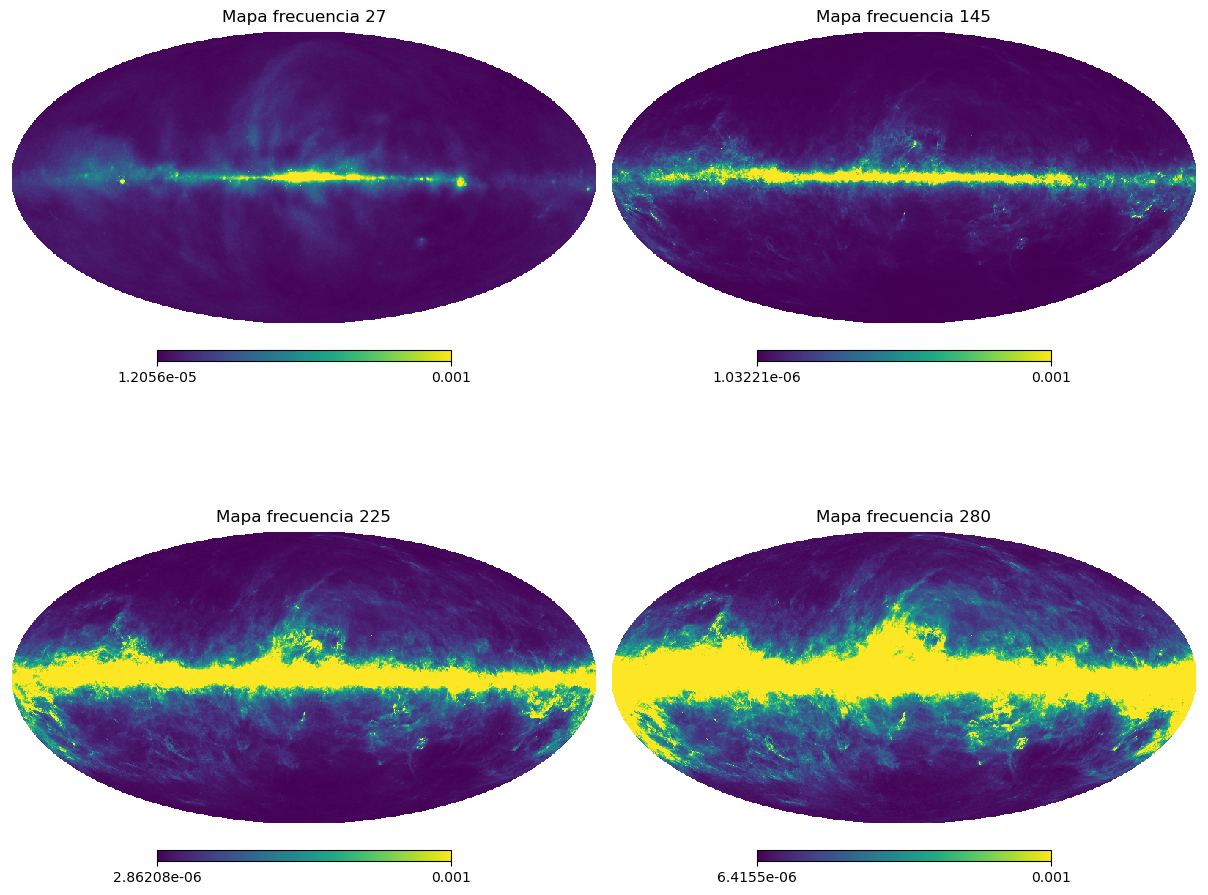

In [13]:
# Recuperar mapas de foreground DEBO REESCALARLO PQ TIENEN Nside = 1024 
ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/Foreground/Simple"

freq = np.array([27, 39, 93, 145, 225, 280])


list_map_fg_T = []
list_map_fg_Q = []
list_map_fg_U = []
list_alm_fg_T = []
list_alm_fg_Q = []
list_alm_fg_U = []
for i,f in enumerate(freq):
    map_T = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_T.fits"))
    map_Q = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_Q.fits"))
    map_U = hp.read_map(os.path.join(ruta_f, f"map_{freq[i]}_U.fits"))
    alm_fg_T = hp.map2alm(map_T, lmax=lmax, use_pixel_weights=True)
    list_alm_fg_T.append(alm_fg_T)
    list_map_fg_T.append(map_T)
    list_map_fg_Q.append(map_Q)
    list_map_fg_U.append(map_U)


plt.figure(figsize=(12,10))

hp.mollview(list_map_fg_T[0], title="Mapa frecuencia 27", max=1e-3, sub=(2,2,1))
hp.mollview(list_map_fg_T[3], title="Mapa frecuencia 145", max=1e-3,sub=(2,2,2))
hp.mollview(list_map_fg_T[4], title="Mapa frecuencia 225", max=1e-3,sub=(2,2,3))
hp.mollview(list_map_fg_T[5], title="Mapa frecuencia 280", max=1e-3,sub=(2,2,4))
plt.show()

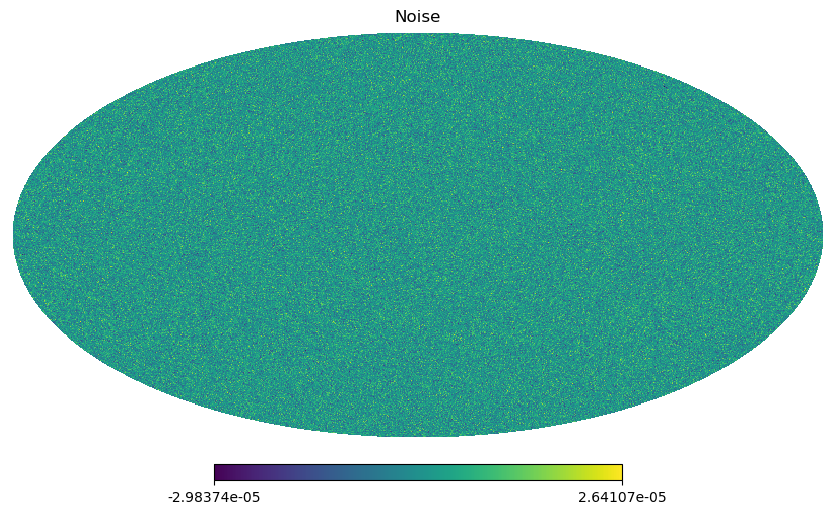

In [14]:
#Recuperamos mapas de ruido
ruta_n = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/camb_outputs/fiducial/Noise_SO"

List_map = []
List_cl_noise = []
freq = np.array([27, 39, 93, 145, 225, 280])

for i,f in enumerate(freq):
    map = hp.read_map(os.path.join(ruta_n, f"map_{freq[i]}_LAT.fits"))
    alm_noise = hp.map2alm(map, lmax=lmax, use_pixel_weights=True)
    cl_noise = hp.sphtfunc.alm2cl(alm_noise,alm_noise,lmax=lmax)
    List_cl_noise.append(cl_noise)
    List_map.append(map)

hp.mollview(List_map[0], title="Noise")


In [23]:
print(type(List_cl_noise[0]), np.shape(List_cl_noise[0]), np.asarray(List_cl_noise[0]).dtype)


<class 'numpy.ndarray'> (1001,) float64


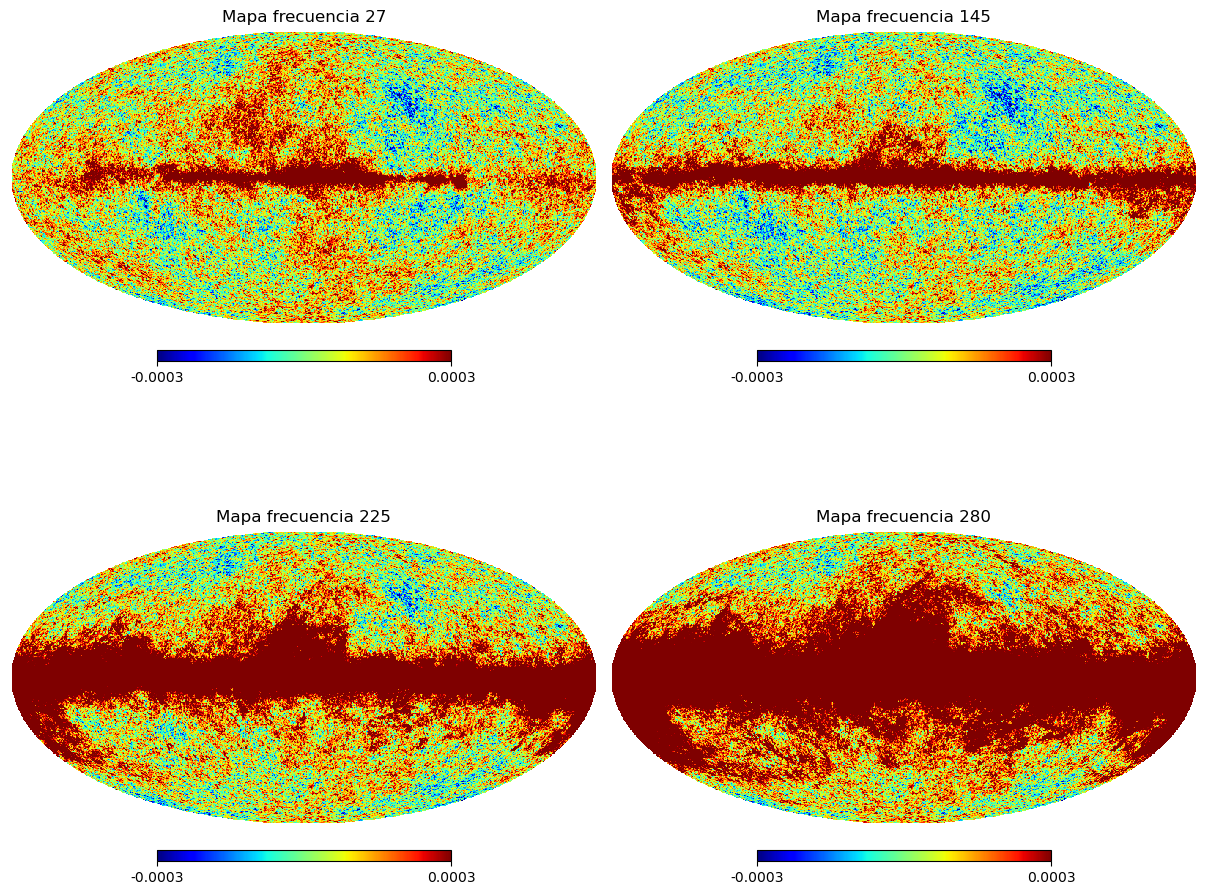

In [15]:
# Mapas CAMB + Foreground + NOISE 

list_map_obs_T = []
list_map_obs_E = []
list_map_obs_B = []
for i,f in enumerate(freq):
    map_obs_T =  list_map_fg_T[i] + map_total_T
    map_obs_Q =  list_map_fg_Q[i] + map_total_Q
    map_obs_U =  list_map_fg_U[i] + map_total_U

    list_map_obs_T.append(map_obs_T)
    list_map_obs_E.append(map_obs_Q)
    list_map_obs_B.append(map_obs_U)

plt.figure(figsize=(12,10))

hp.mollview(list_map_obs_T[0], title="Mapa frecuencia 27", min=-3e-4, max=3e-4, sub=(2,2,1), cmap = "jet")
hp.mollview(list_map_obs_T[3], title="Mapa frecuencia 145", min=-3e-4, max=3e-4,sub=(2,2,2), cmap = "jet")
hp.mollview(list_map_obs_T[4], title="Mapa frecuencia 225", min=-3e-4, max=3e-4,sub=(2,2,3), cmap = "jet")
hp.mollview(list_map_obs_T[5], title="Mapa frecuencia 280", min=-3e-4, max=3e-4,sub=(2,2,4), cmap = "jet")
plt.show()


## MAPA OBSERVADO

Recordemos que nos guiaremos de esta formula:

$$ a_{\ell m}^{\nu, obs} = (a_{\ell m}^{s} + a_{\ell m}^{fg,\nu})B_\ell^{\nu}P_{\ell}^{W} + a_{\ell m}^{\nu, noise} $$

por lo que haremos esta suma haremos el HILC para aplicar al final el wiener filter y ver que resulta.

Trabajaremos solamente con temperatura para aprender, pero luego debemos hacerlo para Q y U ---> E y B

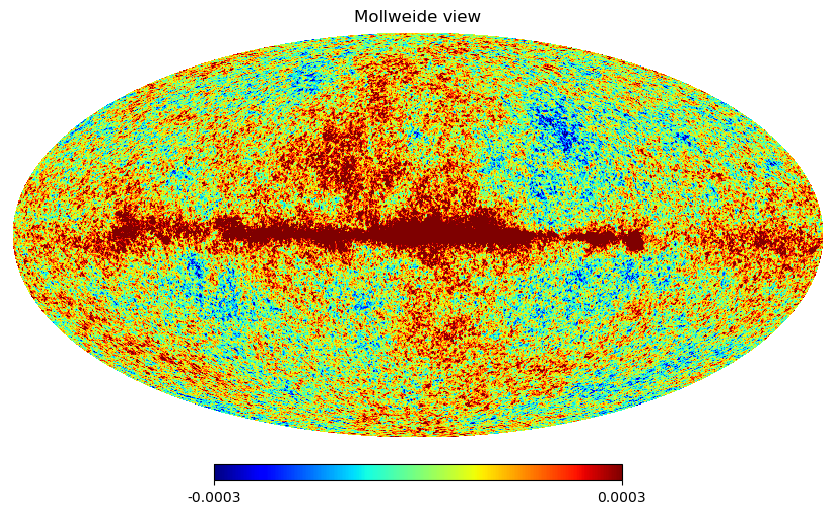

In [27]:
# Funcion Window depende solo de Nside 

w_pix = hp.pixwin(nside, lmax=lmax)

#Funcion Beam
FWHM = np.array([7.4, 5.1, 2.2, 1.4, 1.0, 0.9])*np.pi / (180 * 60) #en radianes

list_alm_obs_T = []
list_transfer = []
for i, fwhm in enumerate(FWHM):
    beam = hp.sphtfunc.gauss_beam(fwhm=FWHM[i], lmax=lmax)
    transfer = beam * w_pix
    list_transfer.append(transfer)
    alm_noise = hp.map2alm(List_map[i], lmax=lmax, use_pixel_weights=True)
    alm_fg_s_T = alms_total[0] + list_alm_fg_T[i]

    alm_window = hp.almxfl(alm_fg_s_T, transfer)
    list_alm_obs_T.append(alm_window + alm_noise) #+ alm_noise

# Ver mapa de hacer el beam y window function
map_obs_T = hp.alm2map(list_alm_obs_T[0], nside=nside, lmax=lmax)

hp.mollview(map_obs_T,  min=-3e-4, max=3e-4, cmap = "jet") # min=-3e-4, max=3e-4,



## Hacemos HILC

En principio calculamos:

$$ a_{l,m}^{clean} = \sum w_{l}^\nu \frac{a_{l,m}}{B_l^\nu P_l^W} $$

Donde los pesos estaran dados por minimizar la varianza y la restriccion $ \sum w_l^\nu = 1 $, los pesos se calculan:

$$ w_l = \frac{\hat C_l^{-1} \mathbf{1}}{\mathbf{1}^T \hat C_l^{-1} \mathbf{1}} $$



In [28]:

# Calculamos la matriz de covarianza entre diferentes frecuencias
nfreq = len(freq)
Cl = np.zeros((nfreq, nfreq, lmax+1))

for i in range(nfreq):
    for j in range(nfreq):
        Cl[i,j,:] = hp.alm2cl(list_alm_obs_T[i], list_alm_obs_T[j])

one = np.ones(nfreq) # vector de 1

# Pesos
weights = np.zeros((lmax+1, nfreq))

for ell in range(2, lmax+1):
    C = Cl[:,:,ell]           # matriz nfreq x nfreq
    Ci = np.linalg.inv(C)     # invierte la matriz
    num = Ci @ one
    den = one @ Ci @ one
    weights[ell,:] = num / den

alm_clean = np.zeros_like(list_alm_obs_T[0])
Nl_HILC = np.zeros(lmax+1)
for i in range(nfreq):
    deconvolved_T = hp.almxfl(list_alm_obs_T[i], 1/list_transfer[i]) 
    alm_clean += hp.almxfl(deconvolved_T, weights[:, i])
    deconvolved_N = List_cl_noise[i]/(list_transfer[i]**2)
    Nl_HILC += (weights[:, i]**2)*deconvolved_N
    

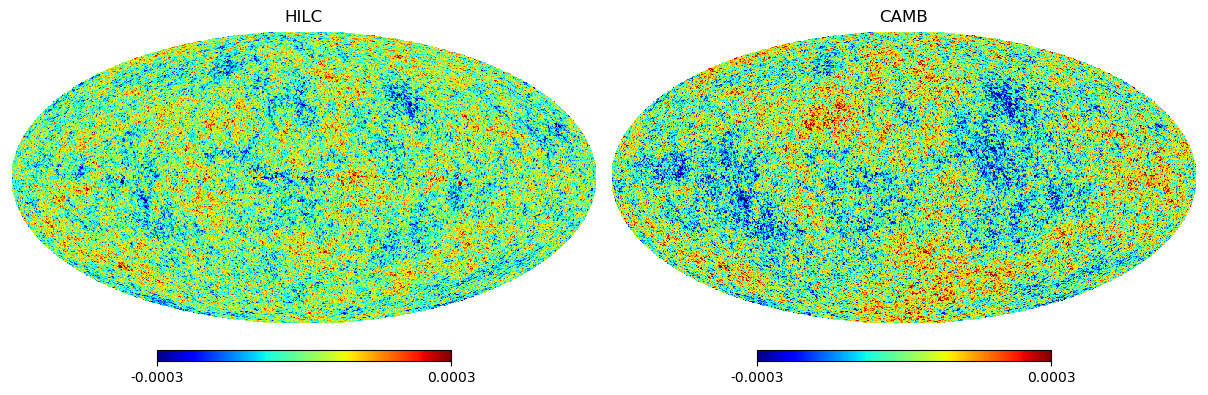

In [29]:
map_obs_T = hp.alm2map(alm_clean, lmax=lmax, nside=nside)


plt.figure(figsize=(12,10))
hp.mollview(map_obs_T, min=-3e-4, max=3e-4, sub=(2,2,1), title="HILC", cmap = "jet")
hp.mollview(map_total_T, min=-3e-4, max=3e-4, sub=(2,2,2), title="CAMB", cmap = "jet" )
plt.show()

## Mascaras???




Mapas multifrecuencia

   

Homogeneizar beam / pixwin

   

HILC  -->  mapa CMB + ruido residual

   

Aplicar máscara (apodizada?)

   

alm (mapa enmascarado)

   

Wiener filter

   

Mapa Wiener-filtrado

# Wiener Filter

Los mapas limpios deben filtrarse para eliminar las regiones enmascaradas y reducir la ponderacion de las areas ruidosas, para ello se utiliza el filtro de varianza inversa (o filtro C-inverso). En el caso del ruido y la señal gaussiana, proporciona la reconstruccion a optima de la señal.

La idea es:
* Si en una escala $\ell$ la señal domina --> confia en los datos
* SI en una escala $\ell$ el ruido domina --> atenua esa escala 

$$ s^{WF} = \mathbf{S}(\mathbf{S} + \mathbf{N})^{-1}s^{data} $$

Donde $ s^{WF} = (T^{WF}, Q^{WF}, U^{WF})^{T} $, ademas $ \mathbf{S} $ y $ \mathbf{N} $ son respectivamente las matrices de covarianza de señal y ruido en el espacio de pixeles.

$$ s^{CI}_{\ell,m} = ( \mathbb{C} + \mathbf{N})^{-1}s^{data}_{\ell,m} $$

Donde $  \mathbb{C} $ es la matriz de covarianza de la señal en el espacio armonico, por lo que $ \mathbf{S}  =  \mathbf{y}   \mathbb{C}^{s} \mathbf{y}^{\dagger} $, donde la matriz $ \mathbf{y} $ tiene dimensiones $ 3N_{pix} \times 3L $ y corresponde a los esfericos armonicos de spin ponderado.

La demostracion viene de hacer un estimador lineal optimo de una señal $ d = s + n $

Digamos que $ \hat s _{\ell,m} = W_\ell d_{\ell,m}$, minimizamos el error cuadratico medio (derivar e igualar a 0):

$$ \frac{d}{dW_\ell}\left< |s _{\ell,m} - W_\ell d_{\ell,m}|^2 \right> = 0 $$

$$ \frac{d}{dW_\ell}\left< s^2 _{\ell,m} -2W_\ell s_{\ell,m}d_{\ell,m}  + W^2_\ell d^2_{\ell,m}| \right> = 0 $$

$$ -2 \left< S_{\ell,m}d_{\ell,m} \right> + 2W_\ell \left< d^2_{\ell,m} \right> = 0 $$

$$ W_\ell = \frac{\mathbb{C}^{s}_\ell}{\mathbb{C}^{s}_\ell + \mathbb{N}_\ell} $$

## DUDA

* Como obtengo el ruido residual del HILC ??
Sera asi?

$$ N^{HILC}_\ell = \sum_\nu w^2_{\nu}(\ell)N^\nu_\ell $$

Donde el $ N^\nu_\ell $ es el ruido de SO

* Que beam le entrego a la funcion?? no creo que sea una idea similar a la ecuacion anterio o no??


In [ ]:
from curvedsky import cninv


C_inv = cninv.cnfilter_freq(n = 1, cl=Cl_total[0], bl=bl, iNcov=1/Nl_HILC  ,lmax=lmax)

In [ ]:
### COSAS QUE FALTAN ###

# AÑADIR RUIDO ---> Falta añadir ruido mas complejo 1/f
# Añadir mascaras de SO 
# HACER Wiener Filter para quitar el ruido
# Hacer delensing a ese mapa limpio 


In [1]:
import sys
print(sys.executable)

import curvedsky
print(curvedsky.__file__)

import libcurvedsky
print("libcurvedsky OK")

from curvedsky import rec_lens
print("rec_lens OK")


/home/jorge/miniconda3/envs/cmblensplus/bin/python
/home/jorge/cmblensplus/wrap/curvedsky/__init__.py
libcurvedsky OK
rec_lens OK


## FULL SKY
